# Detecção com Faster R-CNN — Notebook 2/4 (versão 2h)

**Aula:** Detecção de Objetos (2h) — Aprendizagem de Máquina (CDIA)
**Prof. Dr. Rooney Coelho**

## Objetivo
Entender, na prática, como funciona um detector **dois-estágios** (Faster R-CNN):
carregar o modelo pré-treinado em COCO, fazer inferência, aplicar NMS e
realizar um **fine-tuning** rápido sobre um dataset sintético.

## O que vamos cobrir
1. Carregar `fasterrcnn_resnet50_fpn` com pesos COCO.
2. Inferência numa imagem real (cachorro) com visualização de caixas.
3. **NMS** — antes e depois.
4. Dataset sintético (quadrados, círculos, triângulos).
5. **Fine-tuning** trocando a cabeça de classificação (`FastRCNNPredictor`).
6. Inferência com o modelo ajustado.

## Pré-requisitos
- Notebook 1 concluído (caixas, IoU, NMS conceitual).
- PyTorch + torchvision (já no `.venv`).
- MPS (Apple Silicon) ou CPU.


In [1]:
import os

# Habilita fallback de operações MPS não suportadas (cai para CPU)
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.io import decode_image, read_image
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_fpn,
    fasterrcnn_resnet50_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.utils import draw_bounding_boxes

# Reprodutibilidade
SEMENTE = 42
torch.manual_seed(SEMENTE)
np.random.seed(SEMENTE)


def selecionar_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


device = selecionar_device()
print(f"Dispositivo: {device}")
print(f"torch: {torch.__version__} | torchvision: {torchvision.__version__}")


Dispositivo: mps
torch: 2.12.0 | torchvision: 0.27.0


## 1. Modelo pré-treinado

O `torchvision` traz o **Faster R-CNN** já treinado no COCO (80 classes + fundo).
Vamos baixar os pesos (cache local) e colocar em modo `eval`.


In [2]:
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

pesos = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
modelo = fasterrcnn_resnet50_fpn(weights=pesos)
modelo.eval().to(device)

CATEGORIAS_COCO = pesos.meta["categories"]
print(f"Total de classes COCO (inclui __background__): {len(CATEGORIAS_COCO)}")
print("Primeiras 10:", CATEGORIAS_COCO[:10])


Total de classes COCO (inclui __background__): 91
Primeiras 10: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']


## 2. Inferência numa imagem

Vamos carregar uma imagem (cachorro) e passar pelo modelo.
A função abaixo tenta 3 estratégias em ordem: arquivo local,
download da galeria do torchvision e, por fim, uma cena sintética.


Imagem baixada de https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog2.jpg
shape=(3, 500, 500)  dtype=torch.uint8


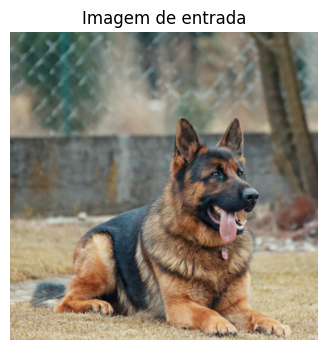

In [3]:
def carregar_imagem_exemplo() -> torch.Tensor:
    """Retorna uma imagem uint8 com shape [3, H, W]."""
    # (1) Arquivo local
    caminho_local = "exemplo.jpg"
    if os.path.exists(caminho_local):
        print(f"Usando arquivo local: {caminho_local}")
        return read_image(caminho_local)

    # (2) Download da galeria do torchvision
    url = "https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog2.jpg"
    try:
        with urllib.request.urlopen(url, timeout=10) as resp:
            dados = resp.read()
        tensor_bytes = torch.frombuffer(bytearray(dados), dtype=torch.uint8)
        imagem = decode_image(tensor_bytes)
        print(f"Imagem baixada de {url}")
        return imagem
    except Exception as exc:  # pragma: no cover - rede pode falhar
        print(f"Falha no download ({exc}); gerando cena sintética.")

    # (3) Fallback sintético
    h, w = 360, 480
    img = torch.full((3, h, w), 200, dtype=torch.uint8)
    img[:, 80:260, 120:340] = torch.tensor([120, 90, 70]).view(3, 1, 1).to(torch.uint8)
    return img


imagem = carregar_imagem_exemplo()
print(f"shape={tuple(imagem.shape)}  dtype={imagem.dtype}")

plt.figure(figsize=(6, 4))
plt.imshow(imagem.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Imagem de entrada")
plt.show()


## 3. Saída do modelo

O Faster R-CNN espera uma **lista** de tensores `float` em `[0, 1]`.
A saída é uma lista de dicionários com `boxes` (xyxy), `labels` e `scores`.


In [4]:
# Normaliza para float [0, 1] e move para o device antes do forward
imagem_float = (imagem.float() / 255.0).to(device)

with torch.no_grad():
    previsoes = modelo([imagem_float])

saida = previsoes[0]
print("Chaves:", list(saida.keys()))
for chave, valor in saida.items():
    print(f"  {chave}: shape={tuple(valor.shape)} dtype={valor.dtype}")

print(f"\nNº total de propostas pós-RoI: {saida['boxes'].shape[0]}")


Chaves: ['boxes', 'labels', 'scores']
  boxes: shape=(3, 4) dtype=torch.float32
  labels: shape=(3,) dtype=torch.int64
  scores: shape=(3,) dtype=torch.float32

Nº total de propostas pós-RoI: 3


Detecções com score >= 0.5: 1


/Users/rooneycoelho/Library/CloudStorage/OneDrive-FundaçãoSãoPaulo/2026.1/Aprendizagem de Máquina/Aula_Deteccao_2h/notebooks/.venv/lib/python3.12/site-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


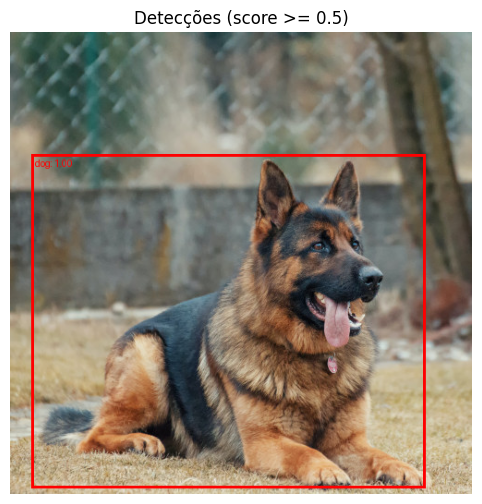

In [5]:
LIMIAR_SCORE = 0.5

boxes = saida["boxes"].cpu()
labels = saida["labels"].cpu()
scores = saida["scores"].cpu()

mascara = scores >= LIMIAR_SCORE
boxes_f = boxes[mascara]
labels_f = labels[mascara]
scores_f = scores[mascara]

rotulos = [
    f"{CATEGORIAS_COCO[lab]}: {sco:.2f}"
    for lab, sco in zip(labels_f.tolist(), scores_f.tolist())
]
print(f"Detecções com score >= {LIMIAR_SCORE}: {len(rotulos)}")

imagem_desenhada = draw_bounding_boxes(
    imagem, boxes_f, labels=rotulos, colors="red", width=3, font_size=16
)

plt.figure(figsize=(8, 6))
plt.imshow(imagem_desenhada.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title(f"Detecções (score >= {LIMIAR_SCORE})")
plt.show()


## 4. NMS na prática

Com um limiar muito permissivo aparecem várias caixas redundantes sobre o
mesmo objeto. O **Non-Max Suppression** mantém apenas a mais forte de cada
grupo (controlado por `iou_threshold`).


Antes do NMS (score >= 0.05): 3 caixas
Depois do NMS (IoU=0.3): 1 caixas


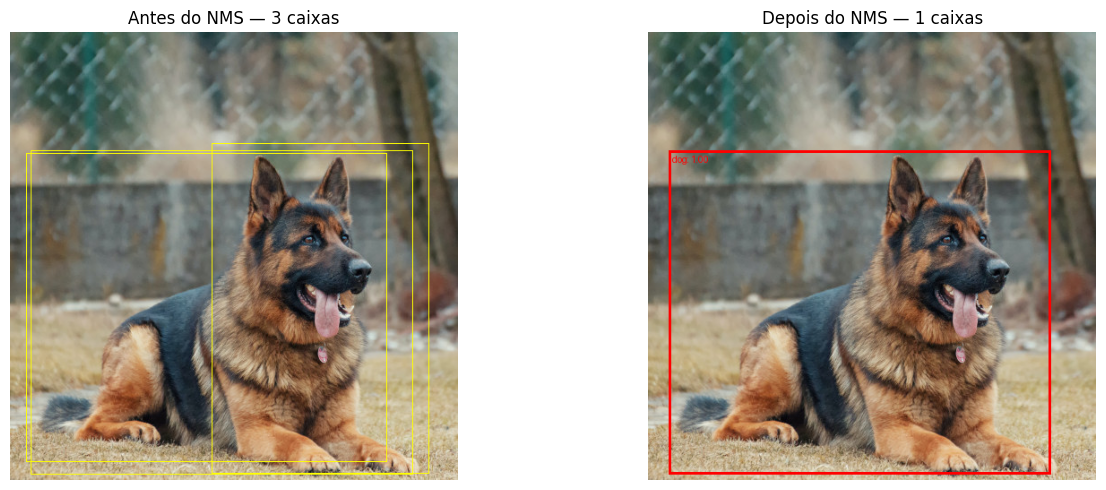

In [6]:
LIMIAR_PERMISSIVO = 0.05
IOU_NMS = 0.3

m_perm = scores >= LIMIAR_PERMISSIVO
b_perm = boxes[m_perm]
s_perm = scores[m_perm]
l_perm = labels[m_perm]
print(f"Antes do NMS (score >= {LIMIAR_PERMISSIVO}): {b_perm.shape[0]} caixas")

indices_mantidos = torchvision.ops.nms(b_perm, s_perm, iou_threshold=IOU_NMS)
b_pos = b_perm[indices_mantidos]
s_pos = s_perm[indices_mantidos]
l_pos = l_perm[indices_mantidos]
print(f"Depois do NMS (IoU={IOU_NMS}): {b_pos.shape[0]} caixas")

img_antes = draw_bounding_boxes(imagem, b_perm, colors="yellow", width=1)
rotulos_pos = [
    f"{CATEGORIAS_COCO[lab]}: {sco:.2f}"
    for lab, sco in zip(l_pos.tolist(), s_pos.tolist())
]
img_depois = draw_bounding_boxes(
    imagem, b_pos, labels=rotulos_pos, colors="red", width=3, font_size=16
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_antes.permute(1, 2, 0).numpy())
axes[0].set_title(f"Antes do NMS — {b_perm.shape[0]} caixas")
axes[0].axis("off")
axes[1].imshow(img_depois.permute(1, 2, 0).numpy())
axes[1].set_title(f"Depois do NMS — {b_pos.shape[0]} caixas")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 5. Dataset sintético para fine-tuning

Para treinar rápido na aula, geramos imagens 128×128 com 2-4 formas:
- classe 1: quadrado
- classe 2: círculo
- classe 3: triângulo
- (classe 0 fica reservada para `__background__`)


In [7]:
class DatasetDeteccaoSintetica(Dataset):
    """Imagens 3x128x128 (float32 em [0,1]) com 2-4 formas + caixas xyxy."""

    NOMES = {0: "fundo", 1: "quadrado", 2: "circulo", 3: "triangulo"}

    def __init__(self, n_amostras: int = 60, tamanho: int = 128, semente: int = 0):
        self.n_amostras = n_amostras
        self.tamanho = tamanho
        self.rng = np.random.default_rng(semente)

    def __len__(self) -> int:
        return self.n_amostras

    def _desenha_quadrado(self, img: np.ndarray, x: int, y: int, lado: int, cor):
        img[:, y : y + lado, x : x + lado] = np.asarray(cor, dtype=np.float32).reshape(3, 1, 1)

    def _desenha_circulo(self, img: np.ndarray, cx: int, cy: int, r: int, cor):
        ys, xs = np.ogrid[: self.tamanho, : self.tamanho]
        mask = (xs - cx) ** 2 + (ys - cy) ** 2 <= r * r
        for c in range(3):
            img[c][mask] = float(cor[c])

    def _desenha_triangulo(self, img: np.ndarray, x: int, y: int, lado: int, cor):
        # triângulo retângulo apontando para cima-esquerda
        for j in range(lado):
            largura = lado - j
            img[:, y + j, x : x + largura] = np.asarray(cor, dtype=np.float32).reshape(3, 1)

    def __getitem__(self, idx: int):
        # Garante float32 desde o início para evitar promoção implícita
        img = np.full((3, self.tamanho, self.tamanho), 0.9, dtype=np.float32)
        n = int(self.rng.integers(2, 5))
        boxes, labels = [], []
        tentativas = 0
        while len(boxes) < n and tentativas < 40:
            tentativas += 1
            classe = int(self.rng.integers(1, 4))
            lado = int(self.rng.integers(18, 36))
            x = int(self.rng.integers(2, self.tamanho - lado - 2))
            y = int(self.rng.integers(2, self.tamanho - lado - 2))
            cor = self.rng.uniform(0.0, 0.7, size=3).astype(np.float32).tolist()

            caixa_nova = [x, y, x + lado, y + lado]
            # evita sobreposição forte
            sobrepoe = False
            for bx in boxes:
                ix1, iy1 = max(bx[0], caixa_nova[0]), max(bx[1], caixa_nova[1])
                ix2, iy2 = min(bx[2], caixa_nova[2]), min(bx[3], caixa_nova[3])
                if ix2 > ix1 and iy2 > iy1:
                    sobrepoe = True
                    break
            if sobrepoe:
                continue

            if classe == 1:
                self._desenha_quadrado(img, x, y, lado, cor)
            elif classe == 2:
                self._desenha_circulo(img, x + lado // 2, y + lado // 2, lado // 2, cor)
            else:
                self._desenha_triangulo(img, x, y, lado, cor)

            boxes.append(caixa_nova)
            labels.append(classe)

        imagem = torch.from_numpy(img)  # float32
        alvo = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }
        return imagem, alvo


treino_ds = DatasetDeteccaoSintetica(n_amostras=40, semente=1)
print(f"Tamanho treino: {len(treino_ds)}")
img0, alvo0 = treino_ds[0]
print(f"img0: shape={tuple(img0.shape)} dtype={img0.dtype}")
print(f"alvo0: {alvo0}")


Tamanho treino: 40
img0: shape=(3, 128, 128) dtype=torch.float32
alvo0: {'boxes': tensor([[ 90.,   5., 121.,  36.],
        [ 50.,  76.,  83., 109.],
        [ 13.,  36.,  48.,  71.]]), 'labels': tensor([2, 2, 1])}


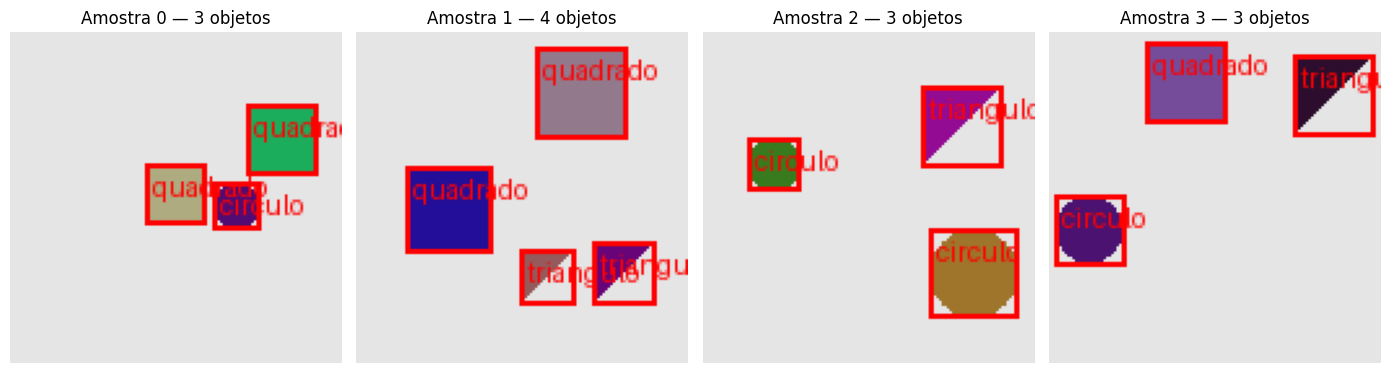

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, range(4)):
    img, alvo = treino_ds[idx]
    img_uint = (img * 255).clamp(0, 255).to(torch.uint8)
    rotulos = [DatasetDeteccaoSintetica.NOMES[int(c)] for c in alvo["labels"]]
    desenhada = draw_bounding_boxes(
        img_uint, alvo["boxes"], labels=rotulos, colors="red", width=2
    )
    ax.imshow(desenhada.permute(1, 2, 0).numpy())
    ax.set_title(f"Amostra {idx} — {len(rotulos)} objetos")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Preparando o modelo + fine-tuning

Para o fine-tuning usamos a versão **MobileNetV3 + FPN** (bem mais leve).
Trocamos só a cabeça de classificação (`FastRCNNPredictor`) para 4 classes
(fundo + 3 formas).


In [9]:
NUM_CLASSES = 4  # fundo + quadrado + circulo + triangulo

modelo_ft = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
in_features = modelo_ft.roi_heads.box_predictor.cls_score.in_features
print(f"in_features da cabeça original: {in_features}")

modelo_ft.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
modelo_ft.to(device)


def collate_fn(batch):
    return tuple(zip(*batch))


loader = DataLoader(
    treino_ds,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
)
print(f"Nº de batches: {len(loader)}")


in_features da cabeça original: 1024


Nº de batches: 10


In [10]:
N_EPOCAS = 3
LR = 5e-4  # taxa pequena porque a cabeca de classificacao foi recem-inicializada

params = [p for p in modelo_ft.parameters() if p.requires_grad]
otimizador = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=5e-4)

modelo_ft.train()
for epoca in range(1, N_EPOCAS + 1):
    perda_acumulada = 0.0
    for imgs, alvos in loader:
        imgs = [img.to(device) for img in imgs]
        alvos = [{k: v.to(device) for k, v in a.items()} for a in alvos]

        perdas = modelo_ft(imgs, alvos)
        soma = sum(perdas.values())

        otimizador.zero_grad()
        soma.backward()
        # Clipping evita explosao de gradiente na cabeca recem-inicializada
        torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
        otimizador.step()

        perda_acumulada += float(soma.detach().cpu())

    media = perda_acumulada / max(len(loader), 1)
    print(f"Época {epoca}/{N_EPOCAS} — loss média: {media:.4f}")


Época 1/3 — loss média: 3.1519


Época 2/3 — loss média: 3.1255


Época 3/3 — loss média: 2.9300


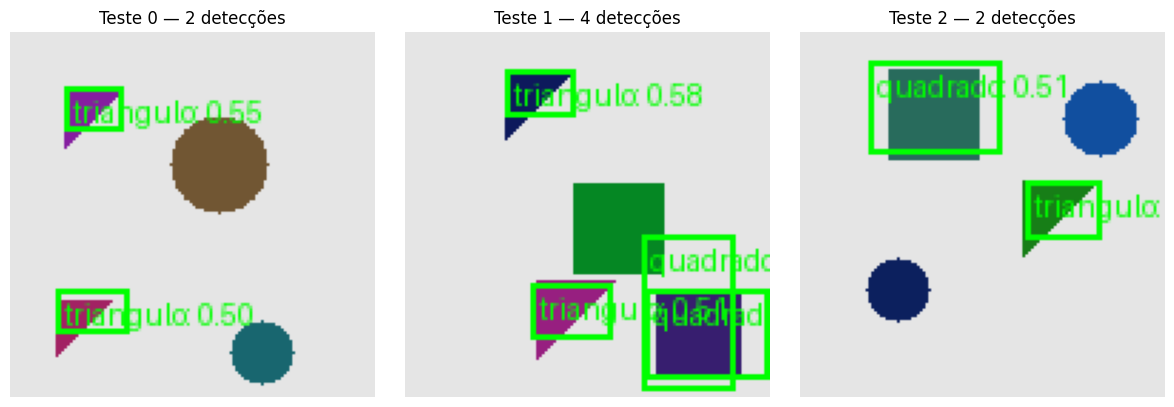

In [11]:
teste_ds = DatasetDeteccaoSintetica(n_amostras=3, semente=999)
modelo_ft.eval()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
with torch.no_grad():
    for ax, idx in zip(axes, range(3)):
        img, _ = teste_ds[idx]
        pred = modelo_ft([img.to(device)])[0]

        boxes_p = pred["boxes"].cpu()
        scores_p = pred["scores"].cpu()
        labels_p = pred["labels"].cpu()

        keep = scores_p >= 0.5
        boxes_p, scores_p, labels_p = boxes_p[keep], scores_p[keep], labels_p[keep]

        rotulos = [
            f"{DatasetDeteccaoSintetica.NOMES.get(int(l), '?')}: {s:.2f}"
            for l, s in zip(labels_p.tolist(), scores_p.tolist())
        ]
        img_uint = (img * 255).clamp(0, 255).to(torch.uint8)
        desenhada = draw_bounding_boxes(
            img_uint, boxes_p, labels=rotulos, colors="lime", width=2
        )
        ax.imshow(desenhada.permute(1, 2, 0).numpy())
        ax.set_title(f"Teste {idx} — {len(rotulos)} detecções")
        ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Exercício

Pequena exploração para entender precisão × recall na prática.


In [12]:
# TODO Exercício 1: varie o limiar de score na secao 8 (0.3, 0.5, 0.7)
# e descreva o efeito em precisao/recall (em comentario).
#
# Dica: refaca a celula 7/8 com cada limiar e conte detecoes verdadeiras vs.
# falsas comparando visualmente com a imagem.
#
# Observacao esperada:
# - Limiar baixo (0.3) -> mais caixas, recall maior, precisao menor.
# - Limiar alto  (0.7) -> menos caixas, precisao maior, recall menor.


## 18. Visualizando os anchors do Faster R-CNN

A RPN (Region Proposal Network) não inventa caixas do zero. Em cada posição
do mapa de features ela ajusta um conjunto fixo de **anchors** (caixas de
referência) com **k = escalas × razões de aspecto** combinações.

In [13]:
# Inspeciona a configuração de anchors do modelo carregado
ag = modelo.rpn.anchor_generator
print("Tamanhos (escalas) por nível do FPN:")
for nivel, tam in enumerate(ag.sizes):
    print(f"  nível {nivel}: {tam}")
print("\nRazões de aspecto por nível:")
for nivel, ratios in enumerate(ag.aspect_ratios):
    print(f"  nível {nivel}: {ratios}")
print(f"\nAnchors por POSIÇÃO em cada nível: "
      f"{len(ag.sizes[0]) * len(ag.aspect_ratios[0])}")
print("(esse mesmo padrão é varrido em cada célula do feature map → milhares no total)")

Tamanhos (escalas) por nível do FPN:
  nível 0: (32,)
  nível 1: (64,)
  nível 2: (128,)
  nível 3: (256,)
  nível 4: (512,)

Razões de aspecto por nível:
  nível 0: (0.5, 1.0, 2.0)
  nível 1: (0.5, 1.0, 2.0)
  nível 2: (0.5, 1.0, 2.0)
  nível 3: (0.5, 1.0, 2.0)
  nível 4: (0.5, 1.0, 2.0)

Anchors por POSIÇÃO em cada nível: 3
(esse mesmo padrão é varrido em cada célula do feature map → milhares no total)


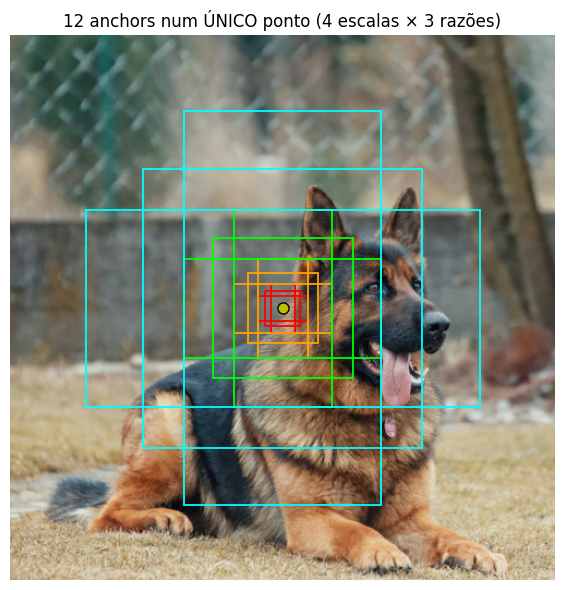

Numa imagem inteira, esses 12 anchors são replicados em CADA célula
do feature map de CADA nível do FPN → dezenas de milhares no total.


In [14]:
# Desenha vários anchors centrados no meio da imagem para visualizar a "biblioteca"
import matplotlib.patches as patches
import numpy as np

H, W = imagem.shape[1:]
cx, cy = W // 2, H // 2

escalas = [32, 64, 128, 256]
razoes = [0.5, 1.0, 2.0]
cores = ["red", "orange", "lime", "cyan"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(imagem.permute(1, 2, 0).numpy())

for cor, escala in zip(cores, escalas):
    for ratio in razoes:
        h_ratio = np.sqrt(ratio)
        w_ratio = 1.0 / h_ratio
        w = escala * w_ratio
        h = escala * h_ratio
        x = cx - w / 2
        y = cy - h / 2
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.3,
                                        edgecolor=cor, facecolor="none"))

ax.plot(cx, cy, "yo", markersize=8, markeredgecolor="black")
n_total = len(escalas) * len(razoes)
ax.set_title(f"{n_total} anchors num ÚNICO ponto "
             f"({len(escalas)} escalas × {len(razoes)} razões)")
ax.axis("off")
plt.tight_layout(); plt.show()

print(f"Numa imagem inteira, esses {n_total} anchors são replicados em CADA célula")
print(f"do feature map de CADA nível do FPN → dezenas de milhares no total.")

### Como a RPN usa esses anchors

Para cada um dos milhares de anchors, a RPN prevê:

1. **objectness score** — probabilidade de existir algum objeto naquela região
2. **4 deltas** — ajustes finos da caixa (Δcx, Δcy, Δw, Δh) sobre o anchor

Os anchors com alto score, depois de receberem o ajuste, viram **propostas**
que entram na cabeça de classificação + regressão final.

## Resumo

- **Faster R-CNN** = backbone (ResNet/MobileNet) + FPN + RPN + RoI Heads.
- Inferência: lista de imagens `float [0,1]` -> lista de dicts `boxes/labels/scores`.
- **NMS** elimina caixas redundantes sobrepostas.
- Fine-tuning: trocar apenas a cabeça (`FastRCNNPredictor`) já permite
  treinar para um número diferente de classes.
- Dataset de detecção entrega `(imagem, {"boxes", "labels"})` — o `collate_fn`
  precisa preservar a estrutura por exemplo (por isso usamos `zip(*batch)`).

Próximo: **`03_yolo_e_metricas.ipynb`** — detector single-stage (YOLO) e
métricas (precision, recall, mAP).